# Rain

Author: **Jakob Balkovec**
Date: **Tue Jan 20th**

This notebook focuses on:
- soil moisture persistence
- rainfall impulse response
- nonlinear regimes and saturation
- identifying modeling gaps not solved by feature stacking alone

For more info `@see domain_analysis/README.md`

In [45]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression

import json

In [20]:
np.random.seed(42)
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (10, 5.5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [22]:
# Paths
SPLIT_ROOT_DIR  = r"/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits"
DERIVED_NEW_DIR = SPLIT_ROOT_DIR + r"/derived_new/"

TRAIN_NEW = DERIVED_NEW_DIR + r"train_derived_new.csv"
TEST_NEW  =  DERIVED_NEW_DIR + r"test_derived_new.csv"
VAL_NEW   = DERIVED_NEW_DIR + r"val_derived_new.csv"
METADATA  = DERIVED_NEW_DIR + r"split_meta_derived_new.json"

FIGURES   = Path(r"/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/domain_analysis/figures")
TABLES    = Path(r"/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/domain_analysis/tables")

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

In [23]:
def load_split(path):
    if path.is_dir():
        files = list(path.glob("*.parquet")) + list(path.glob("*.csv"))
        if not files:
            raise FileNotFoundError(f"No parquet/csv files found in {path}")
        dfs = []
        for f in sorted(files):
            if f.suffix == ".parquet":
                dfs.append(pd.read_parquet(f))
            else:
                dfs.append(pd.read_csv(f))
        return pd.concat(dfs, ignore_index=True)

    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".csv":
        return pd.read_csv(path)

    for ext in [".parquet", ".csv"]:
        p = path.with_suffix(ext)
        if p.exists():
            return pd.read_parquet(p) if ext == ".parquet" else pd.read_csv(p)

    raise FileNotFoundError(f"Could not load split at {path}")

In [25]:
def save_fig(name: str):
    stem = name.replace(" ", "_").replace("/", "_")
    plt.tight_layout()
    plt.savefig(FIGURES / f"{stem}.png", bbox_inches="tight")
    plt.savefig(FIGURES / f"{stem}.pdf", bbox_inches="tight")

In [24]:
train_df = load_split(Path(TRAIN_NEW))
val_df   = load_split(Path(VAL_NEW))
test_df  = load_split(Path(TEST_NEW))

meta = json.loads(Path(METADATA).read_text())

In [29]:
def schema_snapshot(df: pd.DataFrame, name: str, n=5):
    display(df.head(n))
    snap = pd.DataFrame({
        "col": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "n_missing": df.isna().sum().values,
        "pct_missing": (df.isna().mean().values * 100.0),
    }).sort_values(["pct_missing", "col"], ascending=[False, True])
    display(snap)

In [30]:
schema_snapshot(train_df, "train_df")

,station_id,date,longitude,latitude,precip_mm,s1_vv,s1_vh,s2_b4,s2_b8,s2_b11,...,D_z_E_SAR_ratio,D_sa_LST_modis,D_z_LST_modis,D_fft_dom_F_NDMI_kobs30,D_fft_ent_F_NDMI_kobs30,D_fft_dom_E_SAR_ratio_kobs30,D_fft_ent_E_SAR_ratio_kobs30,D_fft_dom_LST_modis_kobs30,D_fft_ent_LST_modis_kobs30,G_DSLR_isnan
0,Spokane,2011-10-06,-117.53,47.420000,2.3,0.065613,0.013690,0.193879,0.301748,0.340476,...,-0.109729,5.899366,1.142856,NaN,NaN,NaN,NaN,NaN,NaN,0
1,Touchet_WA_824,2011-10-06,-117.85,46.116667,5.8,0.057794,0.011176,0.564739,0.602369,0.407894,...,0.291289,7.922108,1.534712,NaN,NaN,NaN,NaN,NaN,NaN,0
2,Quinault,2011-10-06,-123.81,47.510000,0.0,0.203351,0.043233,0.129554,0.333732,0.229553,...,-0.203909,-0.486813,-0.094308,NaN,NaN,NaN,NaN,NaN,NaN,1
3,SourdoughGulch_WA_985,2011-10-06,-117.40,46.233333,5.1,0.066269,0.010976,0.138597,0.202147,0.205514,...,1.208451,8.231796,1.594706,NaN,NaN,NaN,NaN,NaN,NaN,0
4,Darrington,2011-10-06,-121.45,48.540000,1.5,0.083914,0.024101,0.120266,0.315849,0.215994,...,-1.497941,0.280804,0.054399,NaN,NaN,NaN,NaN,NaN,NaN,0


,col,dtype,n_missing,pct_missing
337,H_corr_E_SAR_ratio__F_NDMI_kobs7,float64,8505,50.111949
336,I_ts_spike_s1_vv,float64,7509,44.243460
338,H_corr_E_SAR_ratio__F_NDMI_kobs14,float64,7236,42.634928
339,H_corr_LST_modis__F_NDMI_kobs7,float64,5262,31.004007
340,H_corr_LST_modis__F_NDMI_kobs14,float64,3438,20.256894
...,...,...,...,...
7,s2_b4,float64,0,0.000000
8,s2_b8,float64,0,0.000000
13,slope,float64,0,0.000000
16,soil_moisture_5cm,float64,0,0.000000


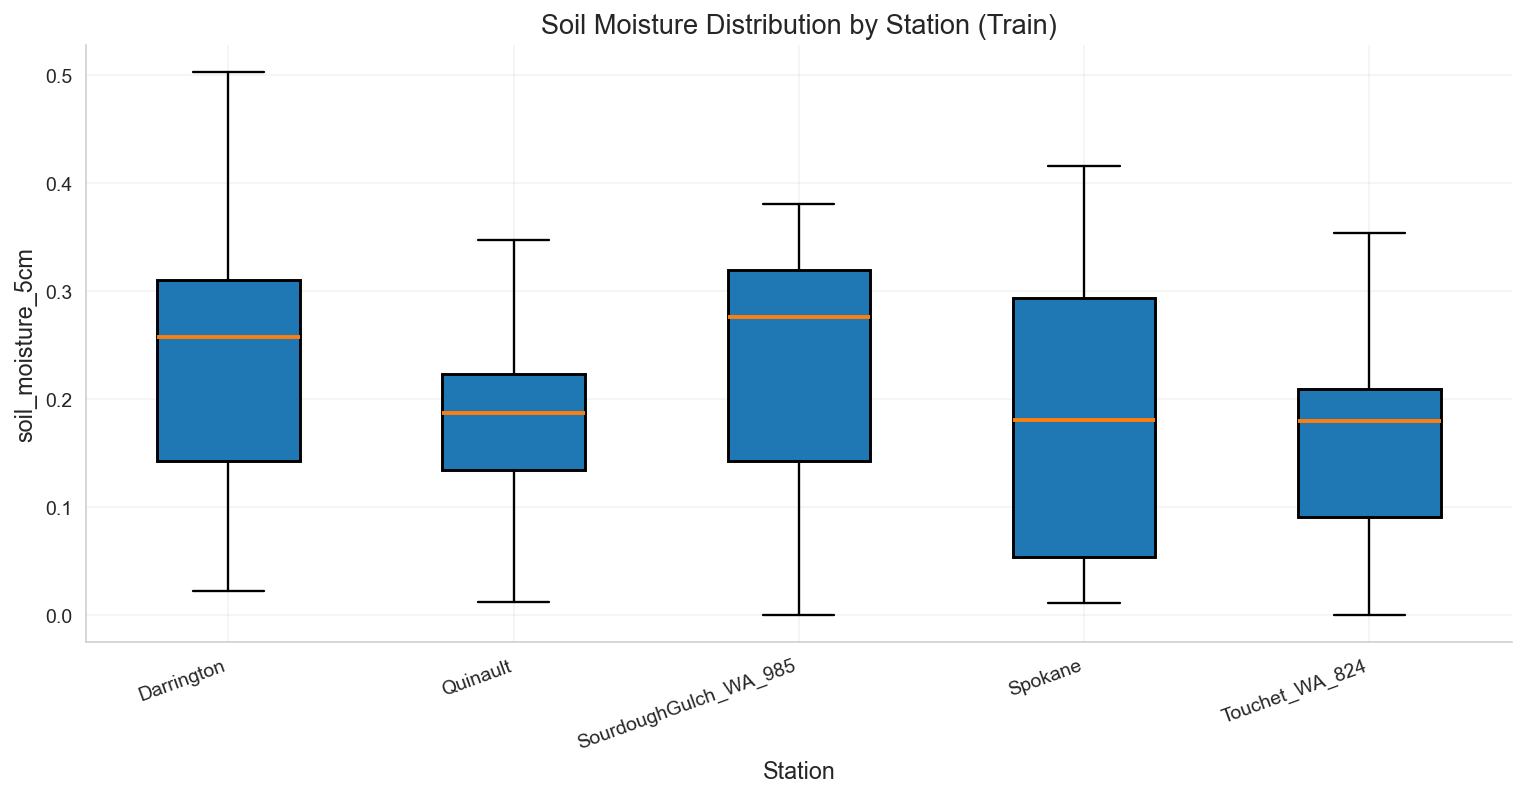

In [33]:
STATION_COL = "station_id"
DATE_COL    = "date"
Y_COL       = "soil_moisture_5cm"

df = train_df[[STATION_COL, DATE_COL, Y_COL]].copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

stations = sorted(df[STATION_COL].unique())

plt.figure(figsize=(11, 5.8))
data = [df.loc[df[STATION_COL] == s, Y_COL].values for s in stations]

bp = plt.boxplot(
    data,
    labels=stations,
    showfliers=False,
    patch_artist=True,
    medianprops={"linewidth": 2},
    boxprops={"linewidth": 1.5},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
)

plt.title("Soil Moisture Distribution by Station (Train)")
plt.xlabel("Station")
plt.ylabel(Y_COL)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

save_fig("01_target_distribution_by_station_train")
plt.show()

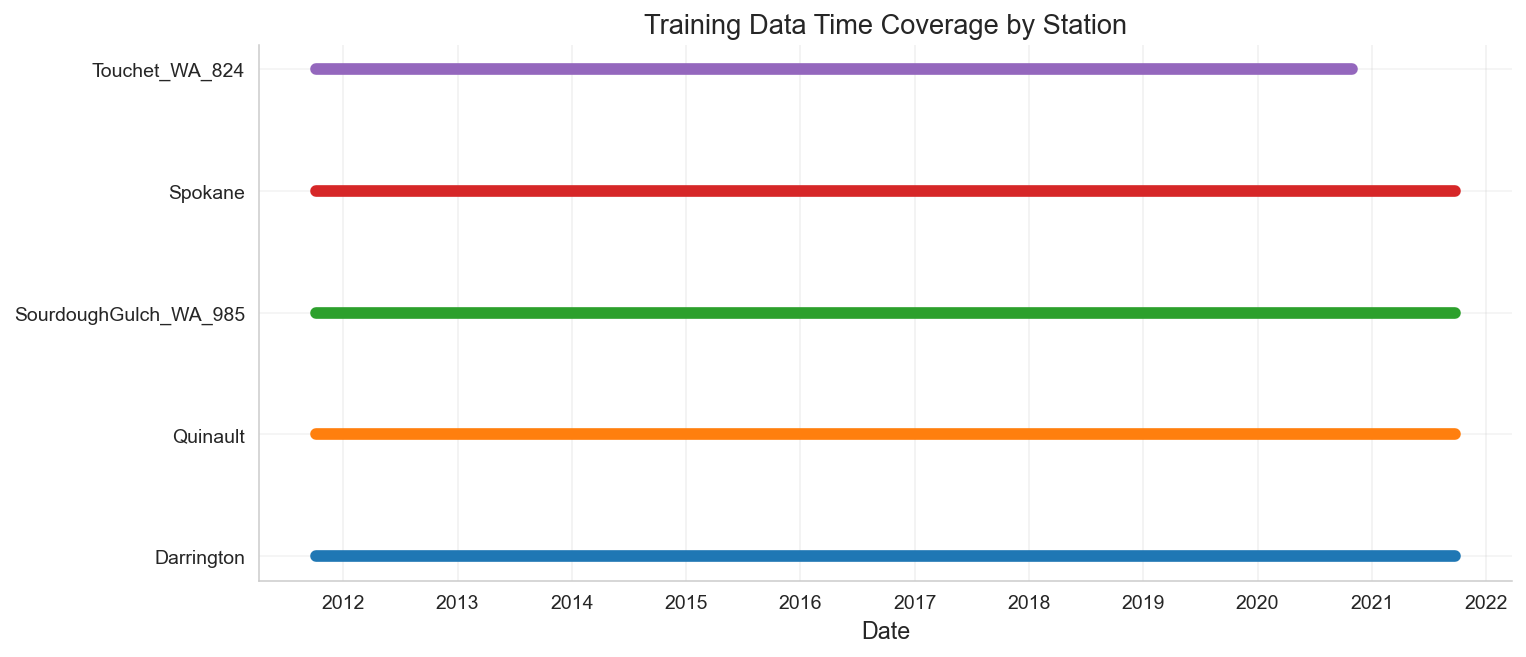

In [34]:
df = train_df[[STATION_COL, DATE_COL]].copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

coverage = (
    df.groupby(STATION_COL)[DATE_COL]
      .agg(start="min", end="max", n_obs="count")
      .reset_index()
      .sort_values("start")
)

plt.figure(figsize=(11, 4.8))

for i, row in enumerate(coverage.itertuples()):
    plt.plot(
        [row.start, row.end],
        [i, i],
        linewidth=6,
        solid_capstyle="round"
    )

plt.yticks(range(len(coverage)), coverage[STATION_COL])
plt.xlabel("Date")
plt.title("Training Data Time Coverage by Station")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

save_fig("02_time_coverage_by_station_train")
plt.show()

In [35]:
coverage

,station_id,start,end,n_obs
0,Darrington,2011-10-06,2021-09-23,3464
1,Quinault,2011-10-06,2021-09-23,3576
2,SourdoughGulch_WA_985,2011-10-06,2021-09-23,3640
3,Spokane,2011-10-06,2021-09-23,2981
4,Touchet_WA_824,2011-10-06,2020-10-28,3311


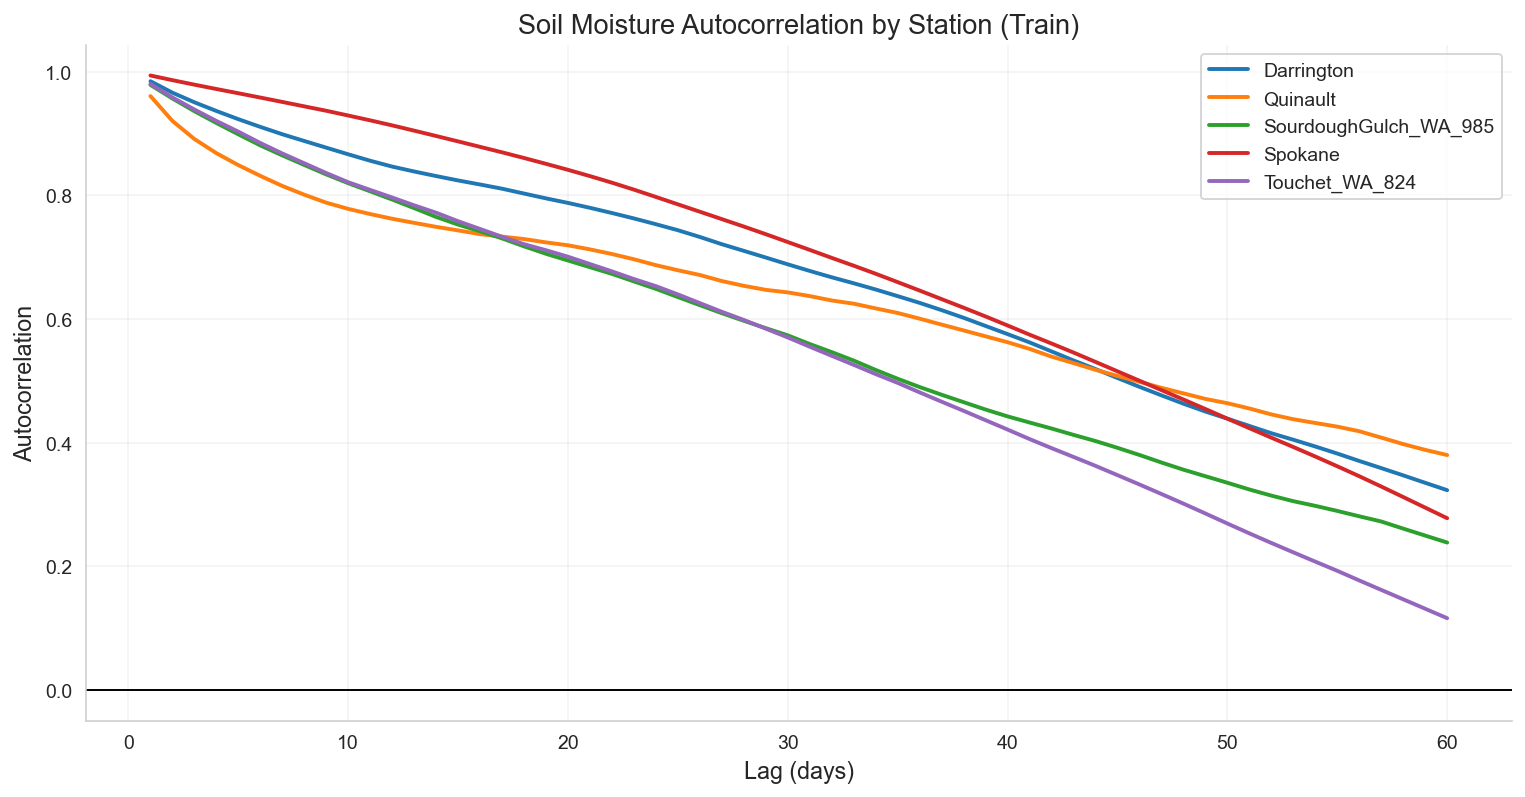

In [36]:
MAX_LAG = 60

df = train_df[[STATION_COL, DATE_COL, Y_COL]].copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values([STATION_COL, DATE_COL])

plt.figure(figsize=(11, 5.8))

for station in df[STATION_COL].unique():
    s = (
        df.loc[df[STATION_COL] == station, Y_COL]
          .dropna()
          .values
    )

    if len(s) < MAX_LAG + 1:
        continue

    acf = [
        np.corrcoef(s[:-lag], s[lag:])[0, 1]
        for lag in range(1, MAX_LAG + 1)
    ]

    plt.plot(
        range(1, MAX_LAG + 1),
        acf,
        label=station,
        linewidth=2
    )

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.title("Soil Moisture Autocorrelation by Station (Train)")
plt.legend()
plt.tight_layout()

save_fig("03_soil_moisture_autocorrelation_by_station")
plt.show()

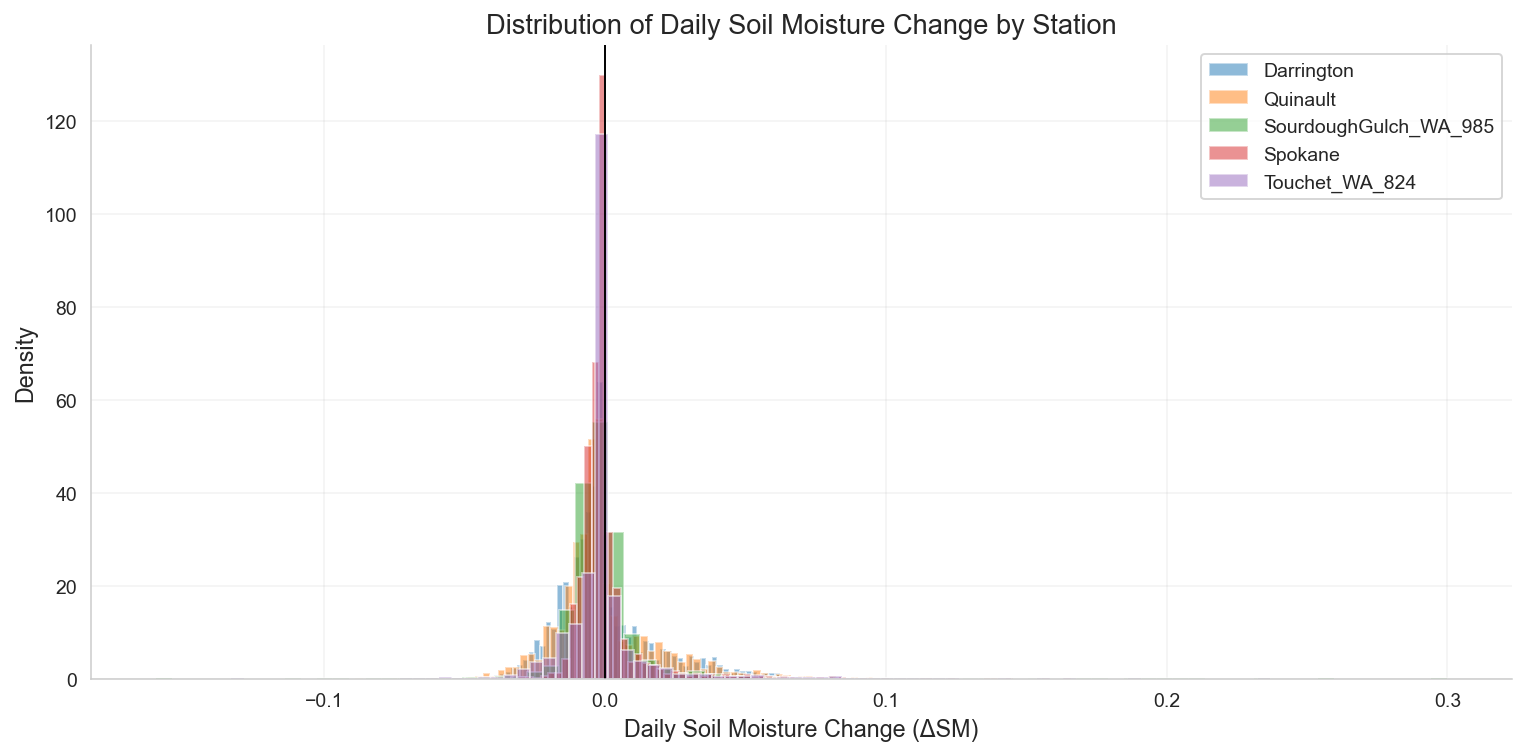

In [ ]:
df = train_df[[STATION_COL, DATE_COL, Y_COL]].copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values([STATION_COL, DATE_COL])

df["delta_sm"] = (
    df.groupby(STATION_COL)[Y_COL]
      .diff()
)

plt.figure(figsize=(11, 5.5))

for station in df[STATION_COL].unique():
    vals = df.loc[df[STATION_COL] == station, "delta_sm"].dropna()
    plt.hist(
        vals,
        bins=80,
        alpha=0.5,
        density=True,
        label=station
    )

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Daily Soil Moisture Change (ΔSM)")
plt.ylabel("Density")
plt.title("Distribution of Daily Soil Moisture Change by Station")
plt.legend()
plt.tight_layout()

save_fig("04_delta_soil_moisture_distribution")
plt.show()

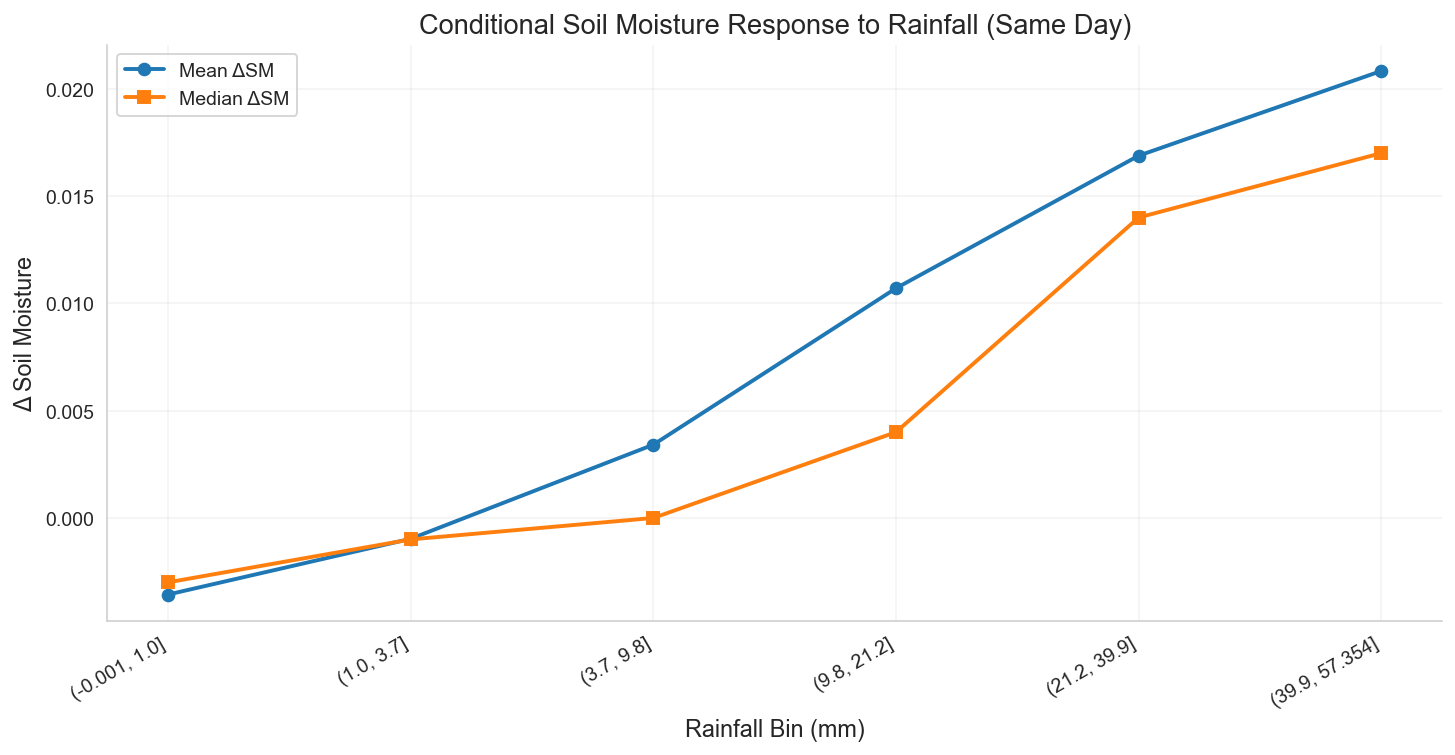

In [ ]:
RAIN_COL = "precip_mm"

df = train_df[[STATION_COL, DATE_COL, Y_COL, RAIN_COL]].copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values([STATION_COL, DATE_COL])
df["delta_sm"] = df.groupby(STATION_COL)[Y_COL].diff()

rain = df[RAIN_COL].values
rain_nonzero = rain[rain > 0]

bins = np.concatenate([
    [0],
    np.quantile(rain_nonzero, [0.25, 0.5, 0.75, 0.9, 0.97, 0.99])
])

df["rain_bin"] = pd.cut(df[RAIN_COL], bins=bins, include_lowest=True)

resp = (
    df.groupby("rain_bin")["delta_sm"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

plt.figure(figsize=(10.5, 5.5))

x = np.arange(len(resp))
plt.plot(x, resp["mean"], marker="o", linewidth=2, label="Mean ΔSM")
plt.plot(x, resp["median"], marker="s", linewidth=2, label="Median ΔSM")

plt.xticks(x, resp["rain_bin"].astype(str), rotation=30, ha="right")
plt.xlabel("Rainfall Bin (mm)")
plt.ylabel("Δ Soil Moisture")
plt.title("Conditional Soil Moisture Response to Rainfall (Same Day)")
plt.legend()
plt.tight_layout()

save_fig("05_rain_to_delta_sm_response_same_day")
plt.show()

In [39]:
resp

,rain_bin,mean,median,count
0,"(-0.001, 1.0]",-0.003568,-0.003,10236
1,"(1.0, 3.7]",-0.000970,-0.001,2225
2,"(3.7, 9.8]",0.003414,0.000,2243
3,"(9.8, 21.2]",0.010704,0.004,1360
4,"(21.2, 39.9]",0.016881,0.014,630
5,"(39.9, 57.354]",0.020829,0.017,181


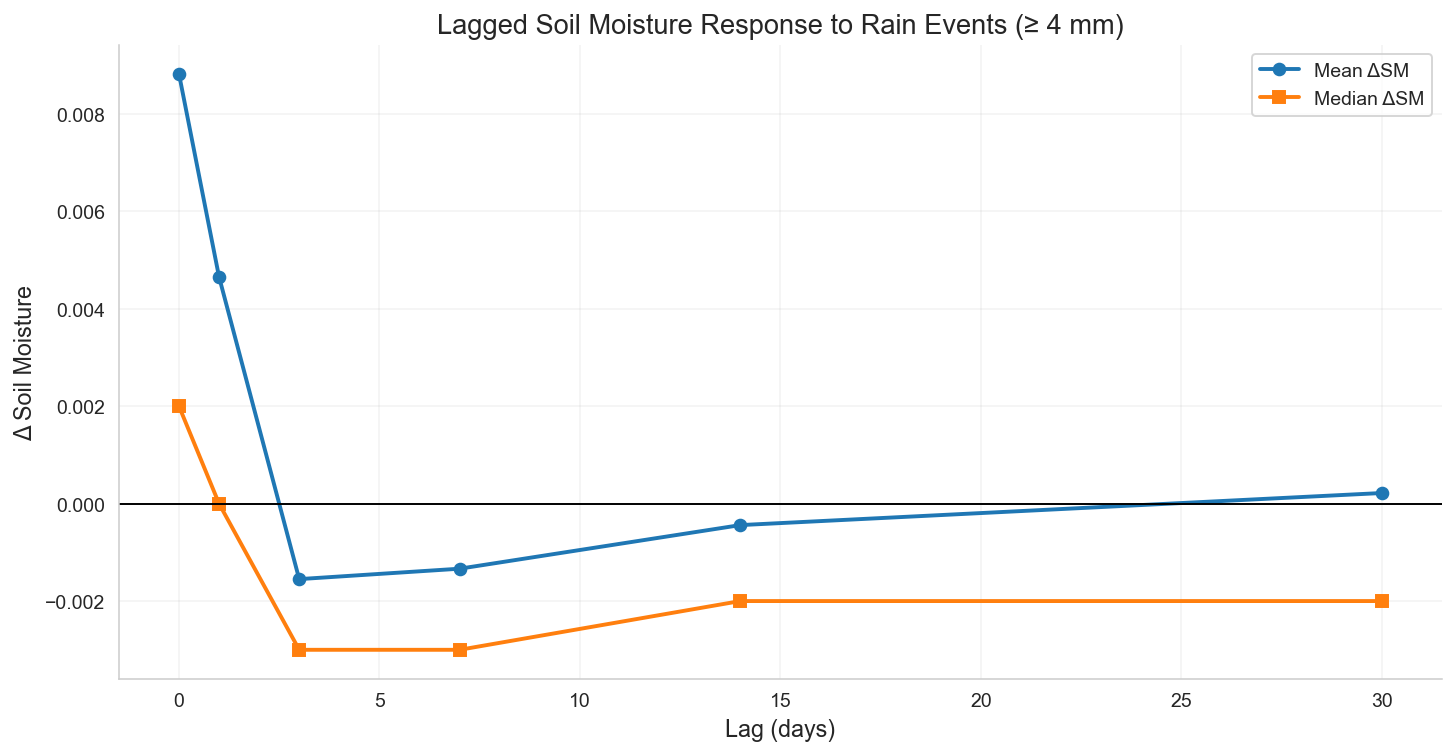

In [40]:
RAIN_COL = "precip_mm"
LAGS = [0, 1, 3, 7, 14, 30]

df = train_df[[STATION_COL, DATE_COL, Y_COL, RAIN_COL]].copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values([STATION_COL, DATE_COL])

df["delta_sm"] = df.groupby(STATION_COL)[Y_COL].diff()

RAIN_THR = 4.0  # from previous plot
df["rain_event"] = (df[RAIN_COL] >= RAIN_THR).astype(int)

results = []

for lag in LAGS:
    df[f"rain_event_lag_{lag}"] = (
        df.groupby(STATION_COL)["rain_event"].shift(lag)
    )

    sub = df[df[f"rain_event_lag_{lag}"] == 1]

    results.append({
        "lag_days": lag,
        "mean_delta_sm": sub["delta_sm"].mean(),
        "median_delta_sm": sub["delta_sm"].median(),
        "n": len(sub)
    })

resp_lag = pd.DataFrame(results)

plt.figure(figsize=(10.5, 5.5))
plt.plot(resp_lag["lag_days"], resp_lag["mean_delta_sm"], marker="o", linewidth=2, label="Mean ΔSM")
plt.plot(resp_lag["lag_days"], resp_lag["median_delta_sm"], marker="s", linewidth=2, label="Median ΔSM")

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Lag (days)")
plt.ylabel("Δ Soil Moisture")
plt.title("Lagged Soil Moisture Response to Rain Events (≥ 4 mm)")
plt.legend()
plt.tight_layout()

save_fig("06_lagged_rain_impulse_response")
plt.show()

In [41]:
resp_lag

,lag_days,mean_delta_sm,median_delta_sm,n
0,0,0.008820,0.002,4395
1,1,0.004653,0.000,4395
2,3,-0.001550,-0.003,4395
3,7,-0.001336,-0.003,4384
4,14,-0.000442,-0.002,4378
5,30,0.000216,-0.002,4369


This is big...

We need to replace:
- Long rain sums
- High-decay API
- Smooth accumulation

With:

- Event-based rain indicators
- Short-horizon kernels
- Separate wetting vs drying signals

In [42]:
RAIN_COL = "precip_mm"
RAIN_THR = 4.0   # from previous plot
K = 7            # short horizon based on lag plot

df = train_df[[STATION_COL, DATE_COL, Y_COL, RAIN_COL]].copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values([STATION_COL, DATE_COL]).reset_index(drop=True)

# base
df["rain_event"] = (df[RAIN_COL] >= RAIN_THR).astype(int)

# lagged
for k in range(0, K + 1):
    df[f"rain_event_lag{k}"] = df.groupby(STATION_COL)["rain_event"].shift(k)
    df[f"rain_mm_lag{k}"]    = df.groupby(STATION_COL)[RAIN_COL].shift(k)

lag_event_cols = [f"rain_event_lag{k}" for k in range(0, K + 1)]
lag_mm_cols    = [f"rain_mm_lag{k}" for k in range(0, K + 1)]

df["rain_event_any_0_7"] = df[lag_event_cols].max(axis=1)
df["rain_event_count_0_7"] = df[lag_event_cols].sum(axis=1)

weights = np.array([1.0, 0.6, 0.2, 0.1, 0.05, 0.02, 0.01, 0.0])

df["rain_event_impulse_0_7"] = (df[lag_event_cols].fillna(0).values * weights).sum(axis=1)
df["rain_mm_impulse_0_7"] = (df[lag_mm_cols].fillna(0).values * weights).sum(axis=1)

def days_since_last_event(group: pd.DataFrame) -> pd.Series:
    ev = group["rain_event"].values
    out = np.zeros(len(ev), dtype=float)
    last = None
    for i in range(len(ev)):
        if ev[i] == 1:
            last = i
            out[i] = 0
        else:
            out[i] = np.nan if last is None else (i - last)
    return pd.Series(out, index=group.index)

df["days_since_rain_event"] = (
    df.groupby(STATION_COL, group_keys=False)
      .apply(days_since_last_event)
      .clip(upper=30)
)

preview_cols = [
    STATION_COL, DATE_COL, Y_COL, RAIN_COL,
    "rain_event", "rain_event_any_0_7", "rain_event_count_0_7",
    "rain_event_impulse_0_7", "rain_mm_impulse_0_7",
    "days_since_rain_event"
]

preview = df[preview_cols].head(300)
preview.to_csv(TABLES / "rain_impulse_feature_preview_train.csv", index=False)

In [43]:
preview.head(12)

,station_id,date,soil_moisture_5cm,precip_mm,rain_event,rain_event_any_0_7,rain_event_count_0_7,rain_event_impulse_0_7,rain_mm_impulse_0_7,days_since_rain_event
0,Darrington,2011-10-06,0.195,1.5,0,0.0,0.0,0.00,1.500,NaN
1,Darrington,2011-10-07,0.205,3.0,0,0.0,0.0,0.00,3.900,NaN
2,Darrington,2011-10-08,0.198,0.2,0,0.0,0.0,0.00,2.300,NaN
3,Darrington,2011-10-09,0.204,1.6,0,0.0,0.0,0.00,2.470,NaN
4,Darrington,2011-10-10,0.216,16.1,1,1.0,1.0,1.00,17.475,0.0
5,Darrington,2011-10-11,0.263,40.0,1,1.0,2.0,1.60,50.180,0.0
6,Darrington,2011-10-12,0.269,9.7,1,1.0,3.0,1.80,37.165,0.0
7,Darrington,2011-10-13,0.253,0.0,0,1.0,3.0,0.90,15.544,1.0
8,Darrington,2011-10-14,0.245,0.0,0,1.0,3.0,0.35,6.779,2.0
9,Darrington,2011-10-15,0.240,0.0,0,1.0,3.0,0.17,3.308,3.0


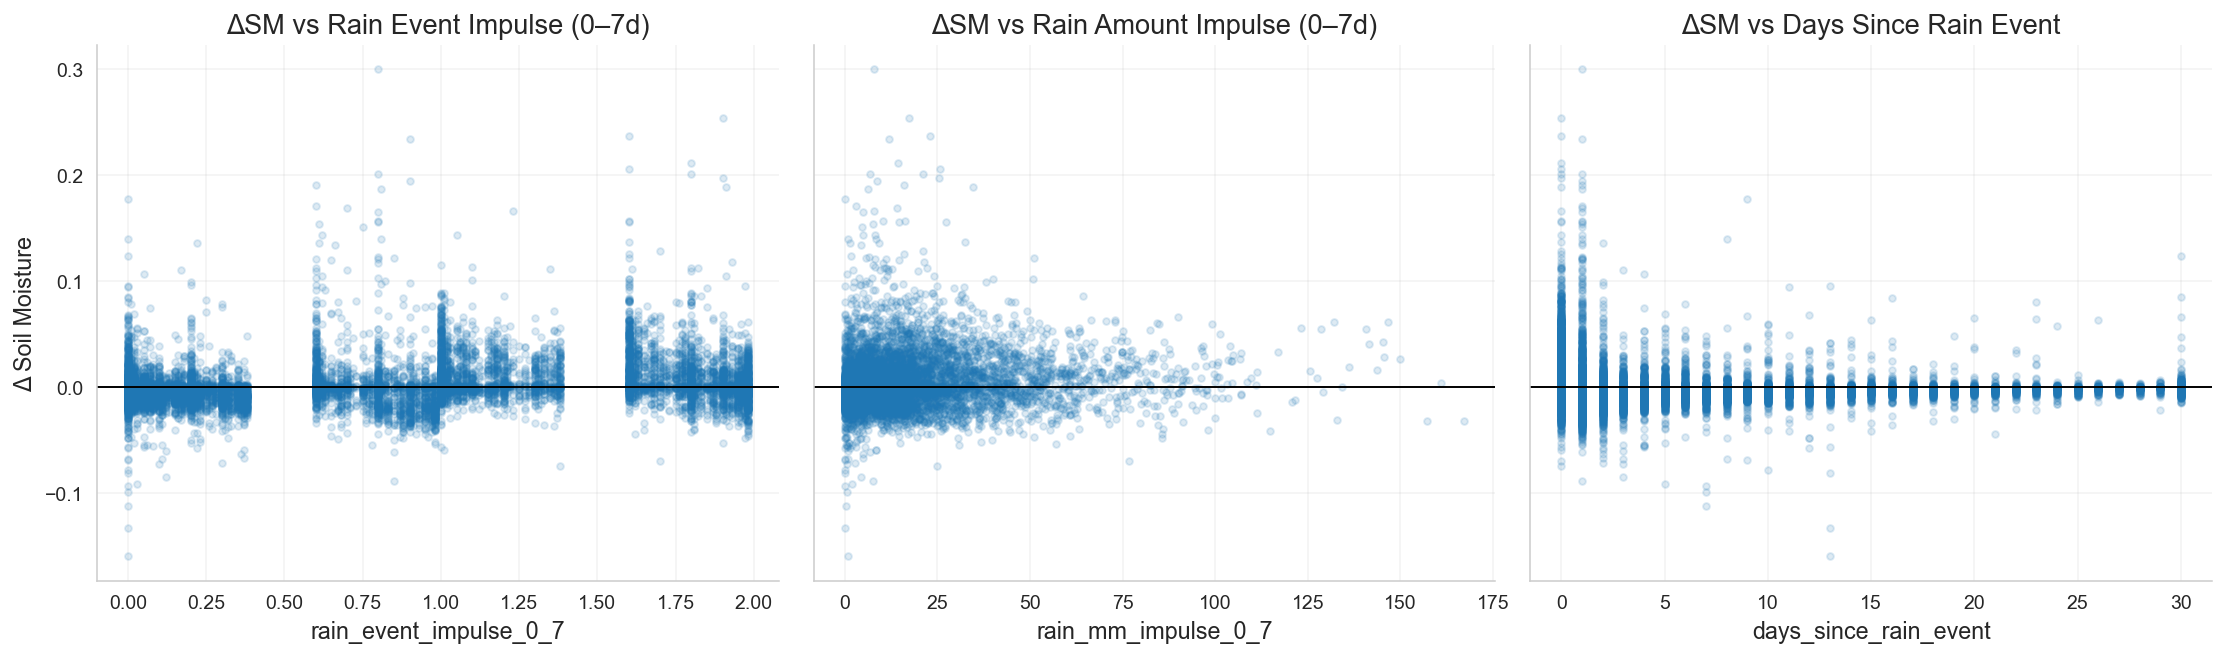

In [44]:
plot_df = df.copy()
plot_df["delta_sm"] = plot_df.groupby(STATION_COL)[Y_COL].diff()
plot_df = plot_df.dropna(subset=["delta_sm", "rain_event_impulse_0_7"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

axes[0].scatter(
    plot_df["rain_event_impulse_0_7"],
    plot_df["delta_sm"],
    alpha=0.15,
    s=12
)
axes[0].set_title("ΔSM vs Rain Event Impulse (0–7d)")
axes[0].set_xlabel("rain_event_impulse_0_7")
axes[0].set_ylabel("Δ Soil Moisture")

axes[1].scatter(
    plot_df["rain_mm_impulse_0_7"],
    plot_df["delta_sm"],
    alpha=0.15,
    s=12
)
axes[1].set_title("ΔSM vs Rain Amount Impulse (0–7d)")
axes[1].set_xlabel("rain_mm_impulse_0_7")

axes[2].scatter(
    plot_df["days_since_rain_event"],
    plot_df["delta_sm"],
    alpha=0.15,
    s=12
)
axes[2].set_title("ΔSM vs Days Since Rain Event")
axes[2].set_xlabel("days_since_rain_event")

for ax in axes:
    ax.axhline(0, color="black", linewidth=1)

plt.tight_layout()
save_fig("07_delta_sm_vs_rain_impulse_features")
plt.show()

In [48]:
df_eval = df.copy()
df_eval = df_eval.sort_values([STATION_COL, DATE_COL])
df_eval["delta_sm"] = df_eval.groupby(STATION_COL)[Y_COL].diff()

OLD_KEYS = [STATION_COL, DATE_COL]
old_cols = [c for c in train_df.columns if any(k in c for k in ["rain_sum", "api", "dslr"])]
old_df = train_df[OLD_KEYS + old_cols].copy()
old_df[DATE_COL] = pd.to_datetime(old_df[DATE_COL])

df_eval = df_eval.merge(old_df, on=OLD_KEYS, how="left")

NEW_RAIN_FEATURES = [
    "rain_event_impulse_0_7",
    "rain_mm_impulse_0_7",
    "days_since_rain_event",
    "rain_event_any_0_7",
    "rain_event_count_0_7",
]

FEATURES = old_cols + NEW_RAIN_FEATURES

eval_df = df_eval[["delta_sm"] + FEATURES].dropna()
y = eval_df["delta_sm"].values

rows = []
for col in FEATURES:
    x = eval_df[col].values
    rows.append({
        "feature": col,
        "pearson_r": float(np.corrcoef(x, y)[0, 1]),
        "spearman_r": float(pd.Series(x).corr(pd.Series(y), method="spearman")),
        "mutual_info": float(mutual_info_regression(x.reshape(-1, 1), y, random_state=42)[0]),
    })

signal_df = (
    pd.DataFrame(rows)
    .sort_values("mutual_info", ascending=False)
    .reset_index(drop=True)
)

signal_df.to_csv(TABLES / "rain_feature_signal_comparison.csv", index=False)

In [49]:
signal_df

,feature,pearson_r,spearman_r,mutual_info
0,rain_event_impulse_0_7,0.241701,0.182326,0.198464
1,days_since_rain_event,-0.101711,-0.176837,0.185025
2,G_rain_sum_30d,-0.009083,-0.058565,0.164608
3,rain_mm_impulse_0_7,0.186646,0.188856,0.159196
4,G_rain_sum_3d,0.058092,0.118242,0.138250
5,G_rain_sum_7d,0.008498,0.018281,0.133616
6,rain_event_count_0_7,0.043832,0.030802,0.106694
7,rain_event_any_0_7,0.090183,0.038913,0.084817


**Add**:

- `rain_event_impulse_0_7`
- `rain_mm_impulse_0_7`
- `days_since_rain_event`

**Maybe Keep**:
`G_rain_sum_30d` OR a seasonal proxy (DOY / harmonic)

**Remove or De-Emphasize**:
- `rain_sum_7d`
- `rain_sum_14d`
- high-decay API variants